In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm
import torch.nn.functional as F

from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


parameter

In [3]:
num_epochs = 6
batch_size = 100
learning_rate = 0.001

train_dir = "../data/Train"
test_dir = "../data/Test"

In [4]:
class Imagedataset(Dataset):
    def __init__ (self, data_dir, transform = None):
        self.data = ImageFolder(data_dir, transform= transform)
    def __len__ (self):
        return len(self.data)
        
    def __getitem__(self, idx):
        return self.data[idx]
    
    @property
    def classes(self):
        return self.data.classes

In [5]:
Id_to_class = {v : k for k, v in ImageFolder(train_dir).class_to_idx.items()}

print(Id_to_class)

{0: 'Fake', 1: 'Real'}


In [6]:
tran = transforms.Compose([
    transforms.Resize((250, 250)),
    transforms.ToTensor(),
]
)
 
train_dataset = Imagedataset(train_dir, tran)
test_dataset = Imagedataset(test_dir, tran)

dataloader

In [7]:
train_Loader = DataLoader(train_dataset, batch_size, shuffle=True)
test_Loader = DataLoader(test_dataset, batch_size, shuffle=False)

## CNN module

In [8]:
print(torch.__file__)

c:\Users\reyhan\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\__init__.py


In [8]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.con1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.con2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16*59*59, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 16)
        self.fc4 = nn.Linear(16, 8)
        self.fc5 = nn.Linear(8, 2)
        
    def forward(self, x):
        x = self.pool(F.relu(self.con1(x)))
        x = self.pool(F.relu(self.con2(x)))
        x = x.view(-1, 16*59*59)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = self.fc5(x)
        return x


In [22]:
model = ConvNet().to(device)
model.load_state_dict(torch.load('../cnn_81_86.pth'))
model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
training_rate = []

n_total_steps = len(train_Loader)

print('start training')
print(f'Epoc: {num_epochs}')

for epoch in range(num_epochs):
    loop = tqdm(train_Loader, leave=False)
    PATH = f'../cnn2_{epoch}.pth'

    for i, (images, labels) in enumerate(loop):
        # origin shape: [4, 3, 32, 32] = 4, 3, 1024
        # input_layer: 3 input channels, 6 output channels, 5 kernel size
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 2993 == 0:
            training_rate.append(loss.item())
            print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')

    torch.save(model.state_dict(), PATH)

print('Finished Training')
#PATH = '../cnn no 2.pth'
#torch.save(model.state_dict(), PATH)

with torch.no_grad():
    n_correct = 0
    n_samples = 0
    n_class_correct = [0 for i in range(2)]
    n_class_samples = [0 for i in range(2)]
    for images, labels in test_Loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        # max returns (value ,index)
        _, predicted = torch.max(outputs, 1)
        n_samples += labels.size(0)
        n_correct += (predicted == labels).sum().item()
        
        for i in range(labels.size(0)):
            label = labels[i]
            pred = predicted[i]
            if (label == pred):
                n_class_correct[label] += 1
            n_class_samples[label] += 1

    acc = 100.0 * n_correct / n_samples
    print(f'Accuracy of the network: {acc} %')

    acc = 100.0 * n_class_correct[0] / n_class_samples[0]
    print(f'Accuracy of Fake: {acc} %')

    acc = 100.0 * n_class_correct[1] / n_class_samples[1]
    print(f'Accuracy of Real: {acc} %')

start training
Epoc: 6


  0%|          | 0/3167 [00:00<?, ?it/s]

c:\Users\reyhan\AppData\Local\Programs\Python\Python312\Lib\site-packages\PIL\Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/6], Step [2993/3167], Loss: 0.2018


  0%|          | 0/3167 [00:00<?, ?it/s]

...

Epoch [4/6], Step [2993/3167], Loss: 0.1678


  0%|          | 0/3167 [00:00<?, ?it/s]

Epoch [5/6], Step [2993/3167], Loss: 0.3073


  0%|          | 0/3167 [00:00<?, ?it/s]

Epoch [6/6], Step [2993/3167], Loss: 0.1370
Finished Training
Accuracy of the network: 85.78126902935087 %
Accuracy of Fake: 80.66576587642795 %
Accuracy of Real: 90.81028861248642 %


In [26]:
model = ConvNet().to(device)
model.load_state_dict(torch.load('../cnn2_2.pth'))
model.to(device)


with torch.no_grad():
    n_correct = 0
    n_samples = 0
    n_class_correct = [0 for i in range(2)]
    n_class_samples = [0 for i in range(2)]
    for images, labels in test_Loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        # max returns (value ,index)
        _, predicted = torch.max(outputs, 1)
        n_samples += labels.size(0)
        n_correct += (predicted == labels).sum().item()
        
        for i in range(labels.size(0)):
            label = labels[i]
            pred = predicted[i]
            if (label == pred):
                n_class_correct[label] += 1
            n_class_samples[label] += 1

    acc = 100.0 * n_correct / n_samples
    print(f'Accuracy of the network: {acc} %')

    acc = 100.0 * n_class_correct[0] / n_class_samples[0]
    print(f'Accuracy of Fake: {acc} %')

    acc = 100.0 * n_class_correct[1] / n_class_samples[1]
    print(f'Accuracy of Real: {acc} %')

Accuracy of the network: 83.31506515649738 %
Accuracy of Fake: 70.90038078860091 %
Accuracy of Real: 95.51986475063399 %


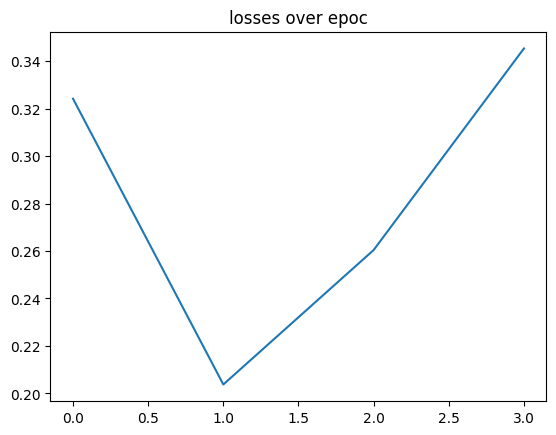

In [66]:
plt.plot(training_rate, label='Training loss')
plt.legend
plt.title('losses over epoc')
plt.show()

## VIsualize result

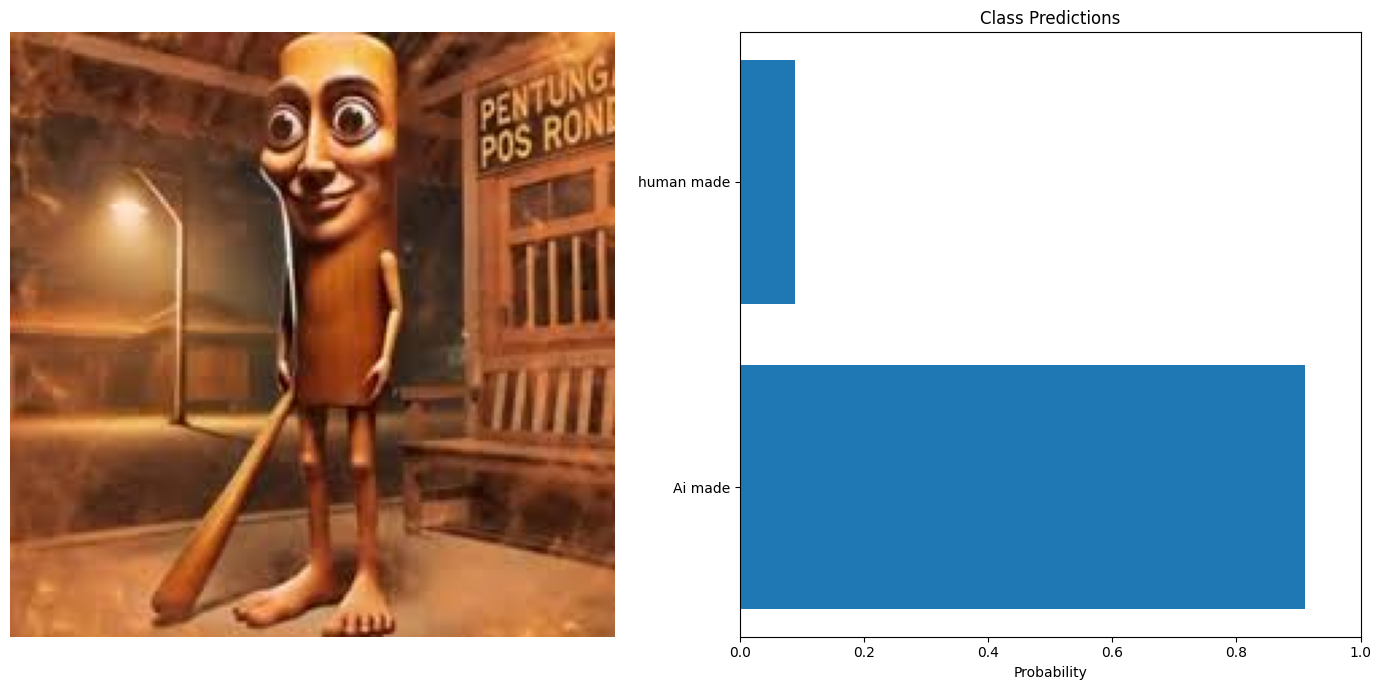

In [14]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

model = ConvNet().to(device)
model.load_state_dict(torch.load('../cnn_81_91.pth'))
model.to(device)

# Load and preprocess the image
def preprocess_image(image_path, transform):
    image = Image.open(image_path).convert("RGB")
    return image, transform(image).unsqueeze(0)

# Predict using the model
def predict(model, image_tensor, device):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
    return probabilities.cpu().numpy().flatten()

# Visualization
def visualize_predictions(original_image, probabilities, class_names):
    fig, axarr = plt.subplots(1, 2, figsize=(14, 7))
    
    # Display image
    axarr[0].imshow(original_image)
    axarr[0].axis("off")
    
    # Display predictions
    axarr[1].barh(class_names, probabilities)
    axarr[1].set_xlabel("Probability")
    axarr[1].set_title("Class Predictions")
    axarr[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

# Example usage
test_image = "../docs/samples/tung tung tung sahur.jpeg"
transform = transforms.Compose([
    transforms.Resize((250, 250)),
    transforms.ToTensor()
])

original_image, image_tensor = preprocess_image(test_image, transform)
probabilities = predict(model, image_tensor, device)

# Assuming dataset.classes gives the class names
class_names = ['Ai made', 'human made']
visualize_predictions(original_image, probabilities, class_names)


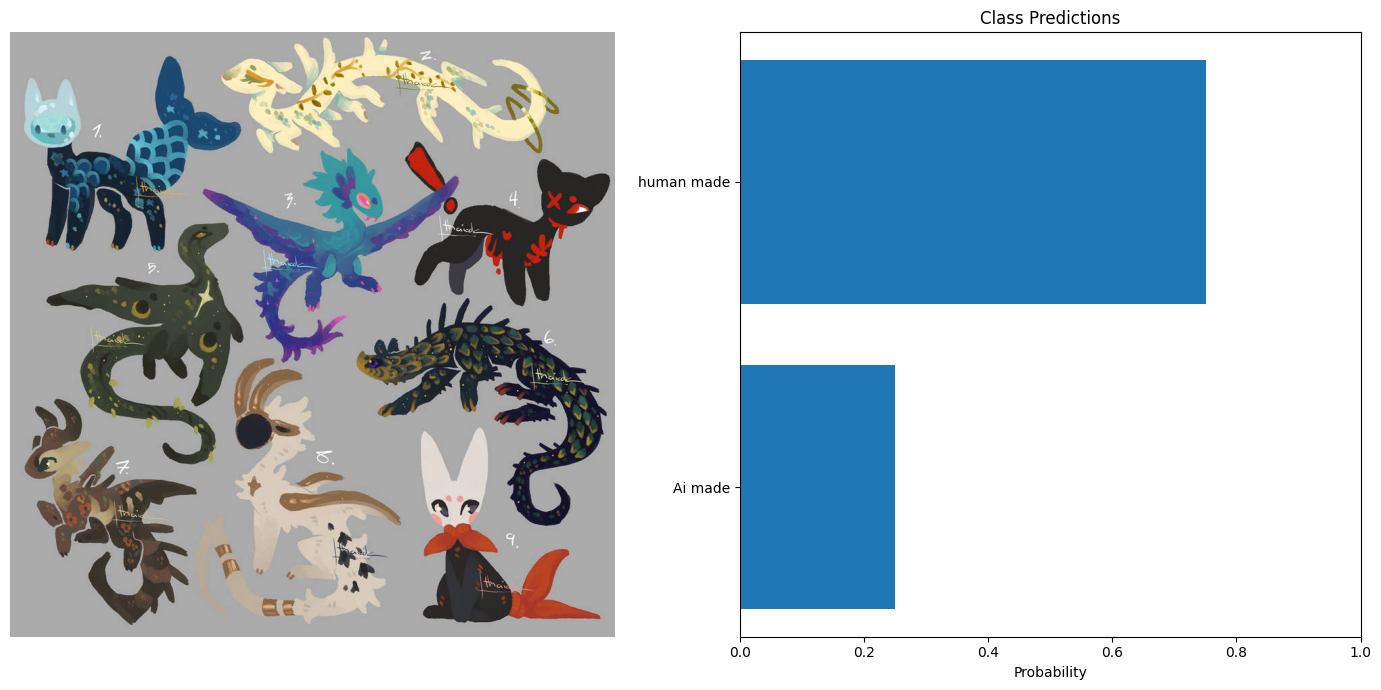

In [17]:
# Example usage
test_image = "../docs/samples/doodle_creatures__closed__by_thaiede_djfc4n3-pre.jpg"
transform = transforms.Compose([
    transforms.Resize((250, 250)),
    transforms.ToTensor()
])

original_image, image_tensor = preprocess_image(test_image, transform)
probabilities = predict(model, image_tensor, device)

# Assuming dataset.classes gives the class names
class_names = ['Ai made', 'human made']
visualize_predictions(original_image, probabilities, class_names)